# FDCH_2 — Data Cleaning, EDA, Outliers & DBSCAN Anomaly Detection

Dataset: `data/Fraud Detection Dataset.csv` — 51,000 transactions with 12 columns, 4.92% labelled fraudulent.

Unlike the dataset used in FDCH1, this one has **substantial missing data** (~5% in five columns), duplicate rows, and at least one corrupted value — which makes it a much better subject for cleaning, outlier detection and unsupervised anomaly detection.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df = pd.read_csv("data/Fraud Detection Dataset.csv")
print(df.shape)
df.head()

(51000, 12)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [3]:
df.columns.tolist()

['Transaction_ID',
 'User_ID',
 'Transaction_Amount',
 'Transaction_Type',
 'Time_of_Transaction',
 'Device_Used',
 'Location',
 'Previous_Fraudulent_Transactions',
 'Account_Age',
 'Number_of_Transactions_Last_24H',
 'Payment_Method',
 'Fraudulent']

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  str    
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  str    
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  str    
 6   Location                          48453 non-null  str    
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  str    
 11  Fraudulent                        51000 non-null  int64  
dtypes: float64(2), 

## 1. Missing values

In [5]:
missing = pd.DataFrame({
    "missing": df.isnull().sum(),
    "percent": (df.isnull().mean() * 100).round(2),
})
print(missing[missing["missing"] > 0].to_string())
print("\ntotal missing cells:", int(df.isnull().sum().sum()))

                     missing  percent
Transaction_Amount      2520     4.94
Time_of_Transaction     2552     5.00
Device_Used             2473     4.85
Location                2547     4.99
Payment_Method          2469     4.84

total missing cells: 12561


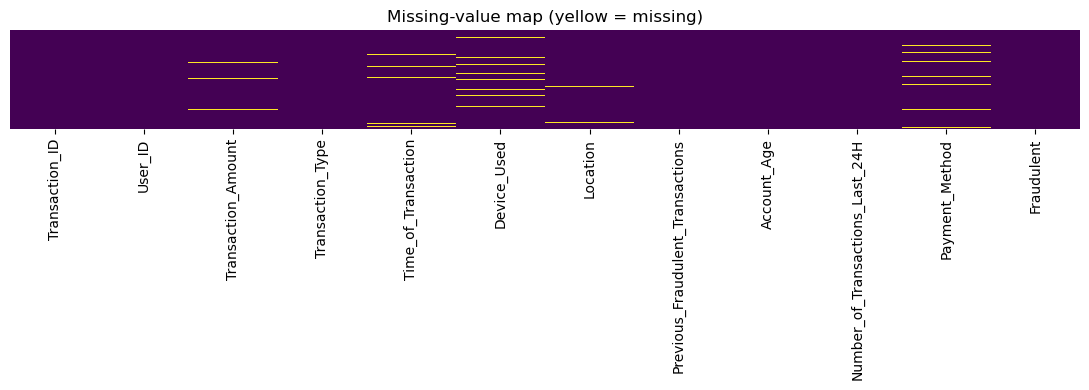

In [6]:
plt.figure(figsize=(11, 4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missing-value map (yellow = missing)")
plt.tight_layout(); plt.show()

### Is the missingness random? (MCAR check)

Before deciding how to handle missing data, check whether it is related to the target. If rows with missing values were disproportionately fraudulent, dropping them would bias the dataset. This test decides whether `dropna()` is safe — it should never be applied blind.

In [7]:
cols_with_na = df.columns[df.isnull().any()].tolist()

rows = []
for col in cols_with_na:
    m = df[col].isna()
    rows.append({"column": col,
                 "n_missing": int(m.sum()),
                 "fraud_rate_missing": round(df.loc[m, "Fraudulent"].mean(), 4),
                 "fraud_rate_present": round(df.loc[~m, "Fraudulent"].mean(), 4)})
mcar = pd.DataFrame(rows)
mcar["difference"] = (mcar["fraud_rate_missing"] - mcar["fraud_rate_present"]).round(4)
print(mcar.to_string(index=False))
print("\noverall fraud rate: %.4f" % df["Fraudulent"].mean())

             column  n_missing  fraud_rate_missing  fraud_rate_present  difference
 Transaction_Amount       2520              0.0496              0.0492      0.0004
Time_of_Transaction       2552              0.0525              0.0490      0.0035
        Device_Used       2473              0.0615              0.0486      0.0129
           Location       2547              0.0483              0.0493     -0.0010
     Payment_Method       2469              0.0425              0.0496     -0.0071

overall fraud rate: 0.0492


The fraud rate is essentially the same whether a value is missing or present — the largest gap is about 1.3 percentage points on `Device_Used`. The missingness is close to **MCAR** (missing completely at random), so dropping those rows would not badly bias the target.

### The cost of `dropna()`

In [8]:
df_dropped = df.dropna()
lost = len(df) - len(df_dropped)
print("rows before :", len(df))
print("rows after  :", len(df_dropped))
print("rows lost   : %d (%.1f%% of the data)" % (lost, lost / len(df) * 100))
print("\nfraud rate — before: %.5f | after: %.5f" % (df["Fraudulent"].mean(), df_dropped["Fraudulent"].mean()))

rows before : 51000
rows after  : 39583
rows lost   : 11417 (22.4% of the data)

fraud rate — before: 0.04922 | after: 0.04881


Dropping rows costs **22.4%** of the dataset. Since only ~5% of values are missing in any one column, most discarded rows are complete in every column but one. Imputation keeps those 11,417 rows, so that is the route taken below — `dropna()` is defensible here but wasteful.

In [9]:
df_clean = df.copy()

num_cols = ["Transaction_Amount", "Time_of_Transaction"]
cat_cols = ["Device_Used", "Location", "Payment_Method"]

for col in num_cols:                       # median: robust to the skew shown later
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cat_cols:                       # mode for categoricals
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("missing cells after imputation:", int(df_clean.isnull().sum().sum()))
print("rows retained:", len(df_clean), "(vs %d if dropna had been used)" % len(df_dropped))

missing cells after imputation: 0
rows retained: 51000 (vs 39583 if dropna had been used)


## 2. Identical values

In [10]:
duplicates = df_clean.duplicated().sum()
print("Duplicate Records:", duplicates)
print("frauds among duplicates:", int(df_clean[df_clean.duplicated()]["Fraudulent"].sum()))

Duplicate Records: 881
frauds among duplicates: 43


### Task 1: Column-wise duplicate count

Per column, how many rows repeat a value already seen — `len(df) - nunique`.

In [11]:
col_dupes = pd.DataFrame({
    "unique": df_clean.nunique(),
    "duplicated_values": len(df_clean) - df_clean.nunique(),
})
col_dupes["pct_duplicated"] = (col_dupes["duplicated_values"] / len(df_clean) * 100).round(2)
print(col_dupes.sort_values("duplicated_values", ascending=False).to_string())

                                  unique  duplicated_values  pct_duplicated
Fraudulent                             2              50998          100.00
Device_Used                            4              50996           99.99
Transaction_Type                       5              50995           99.99
Previous_Fraudulent_Transactions       5              50995           99.99
Payment_Method                         5              50995           99.99
Location                               8              50992           99.98
Number_of_Transactions_Last_24H       14              50986           99.97
Time_of_Transaction                   24              50976           99.95
Account_Age                          119              50881           99.77
User_ID                             4000              47000           92.16
Transaction_Amount                 44822               6178           12.11
Transaction_ID                     50000               1000            1.96


Low-cardinality columns (`Fraudulent`, `Device_Used`, `Payment_Method`) sit at the top by construction — they only have a handful of legal values. The number is only diagnostic for columns that were meant to be near-unique, such as `Transaction_ID`.

In [12]:
# Transaction_ID should be a unique key — check that assumption rather than assuming it.
id_counts = df_clean["Transaction_ID"].value_counts()
print("rows:", len(df_clean), "| unique Transaction_ID:", df_clean["Transaction_ID"].nunique())
print("Transaction_ID is a unique key:", df_clean["Transaction_ID"].is_unique)
print("IDs appearing more than once:", int((id_counts > 1).sum()))

# Are the colliding rows genuinely different transactions, or exact copies?
dup_ids = id_counts[id_counts > 1].index[:2]
print("\nexample colliding IDs:")
print(df_clean[df_clean["Transaction_ID"].isin(dup_ids)]
      .sort_values("Transaction_ID")
      [["Transaction_ID", "User_ID", "Transaction_Amount", "Account_Age", "Fraudulent"]]
      .to_string(index=False))

rows: 51000 | unique Transaction_ID: 50000
Transaction_ID is a unique key: False
IDs appearing more than once: 1000

example colliding IDs:
Transaction_ID  User_ID  Transaction_Amount  Account_Age  Fraudulent
          T148     3640             3372.43           65           0
          T148     3640             3372.43           65           0
            T5     2130             1490.50           57           0
            T5     2130             1490.50           57           0


`Transaction_ID` is **not** a unique key: 1,000 IDs appear twice, and the colliding rows are identical in every other column too. So the 51,000-row file is really **50,000 distinct transactions with 1,000 exact copies appended**.

This matters beyond tidiness — duplicated rows inflate any count or rate computed from the data, and if this were fed to a model they would leak across a train/test split.

## 3. Exploratory analysis

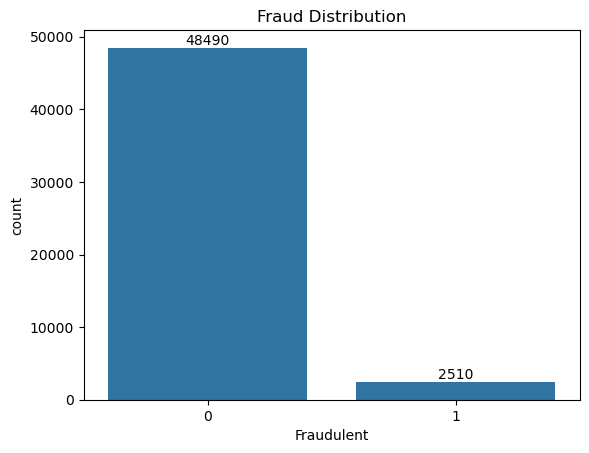

{0: 48490, 1: 2510}
fraud rate: 4.92%


In [13]:
ax = sns.countplot(x="Fraudulent", data=df_clean)
plt.title("Fraud Distribution")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.show()

print(df_clean["Fraudulent"].value_counts().to_dict())
print("fraud rate: %.2f%%" % (df_clean["Fraudulent"].mean() * 100))

At 4.92% this is imbalanced, but far less extremely than the credit-card data in FDCH1 (0.17%) — the minority class is visible on a linear axis without a log scale.

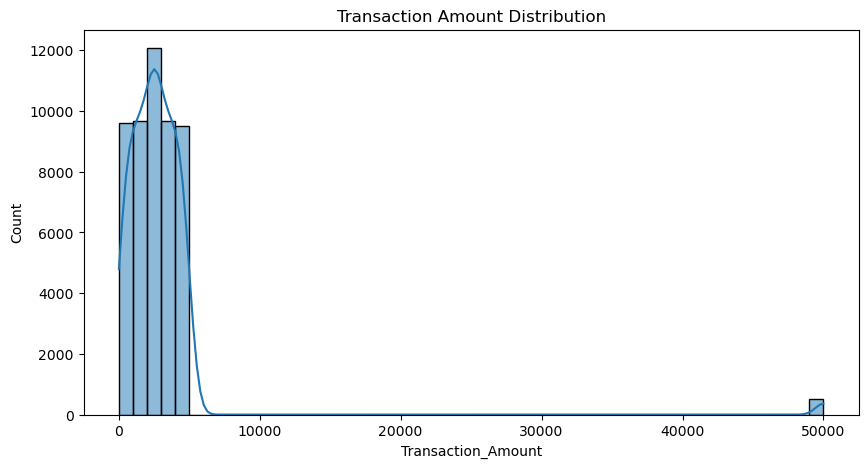

count    51000.00
mean      2972.92
std       4918.80
min          5.03
25%       1333.79
50%       2524.10
75%       3724.99
max      49997.80


In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean["Transaction_Amount"], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

print(df_clean["Transaction_Amount"].describe().round(2).to_string())

The histogram is dominated by a single bar at the far right — a first sign that something is wrong with the largest values. This is investigated in Task 3.

### Task 2: Payment_Method vs Fraudulent

In [15]:
ct = pd.crosstab(df_clean["Payment_Method"], df_clean["Fraudulent"])
ct.columns = ["legit", "fraud"]
ct["total"] = ct.sum(axis=1)
ct["fraud_rate"] = (ct["fraud"] / ct["total"]).round(4)
print(ct.to_string())

                legit  fraud  total  fraud_rate
Payment_Method                                 
Credit Card     11072    574  11646      0.0493
Debit Card      11230    572  11802      0.0485
Invalid Method   1457     73   1530      0.0477
Net Banking     11092    574  11666      0.0492
UPI             13639    717  14356      0.0499


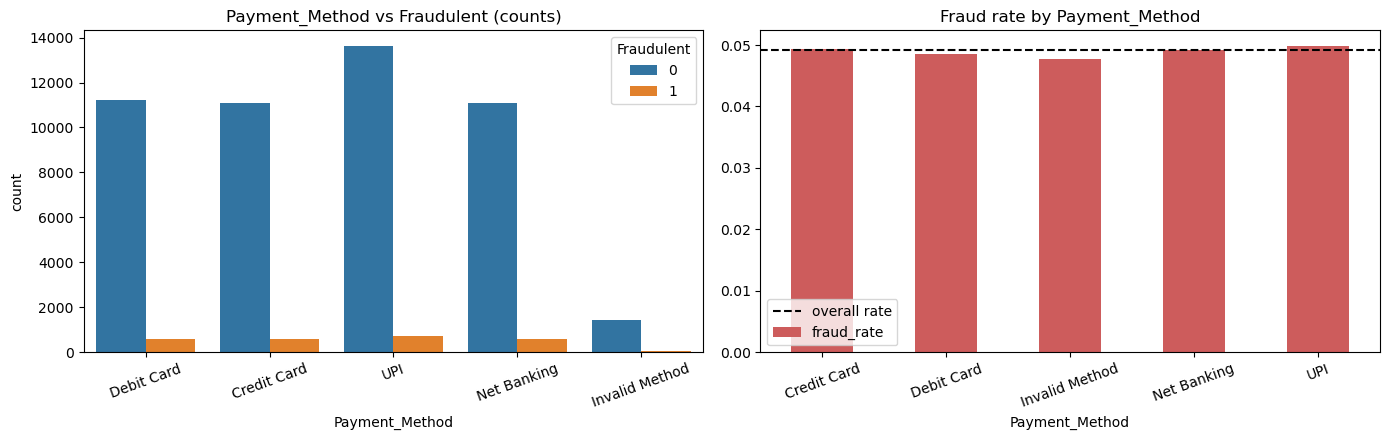

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.countplot(data=df_clean, x="Payment_Method", hue="Fraudulent", ax=ax[0])
ax[0].set_title("Payment_Method vs Fraudulent (counts)")
ax[0].tick_params(axis="x", rotation=20)

ct["fraud_rate"].plot(kind="bar", ax=ax[1], color="indianred")
ax[1].axhline(df_clean["Fraudulent"].mean(), color="k", ls="--", label="overall rate")
ax[1].set_title("Fraud rate by Payment_Method"); ax[1].legend()
ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

### Chi-square: is that variation real?

The bars differ slightly, but small differences appear by chance. A chi-square test of independence decides whether the variation is more than sampling noise.

In [17]:
from scipy.stats import chi2_contingency

for col in ["Payment_Method", "Transaction_Type", "Device_Used", "Location"]:
    table = pd.crosstab(df_clean[col], df_clean["Fraudulent"])
    chi2, p, dof, _ = chi2_contingency(table)
    rates = df_clean.groupby(col)["Fraudulent"].mean()
    print("%-18s chi2=%7.3f  p=%.4f  %s   (fraud rate %.4f - %.4f)"
          % (col, chi2, p, "SIGNIFICANT" if p < 0.05 else "not significant",
             rates.min(), rates.max()))

Payment_Method     chi2=  0.380  p=0.9841  not significant   (fraud rate 0.0477 - 0.0499)


Transaction_Type   chi2=  3.591  p=0.4641  not significant   (fraud rate 0.0465 - 0.0519)
Device_Used        chi2=  3.930  p=0.2692  not significant   (fraud rate 0.0468 - 0.0516)
Location           chi2= 10.517  p=0.1611  not significant   (fraud rate 0.0436 - 0.0550)


**No categorical column is significantly associated with the target.** Every fraud rate sits within about one percentage point of the 4.92% overall rate. This is the defining property of the dataset: the labels carry no learnable relationship to the features, so this notebook treats it as an **unsupervised** problem — finding structure and data-quality faults — rather than attempting classification, which belongs to FDCH1.

## 4. Correlation

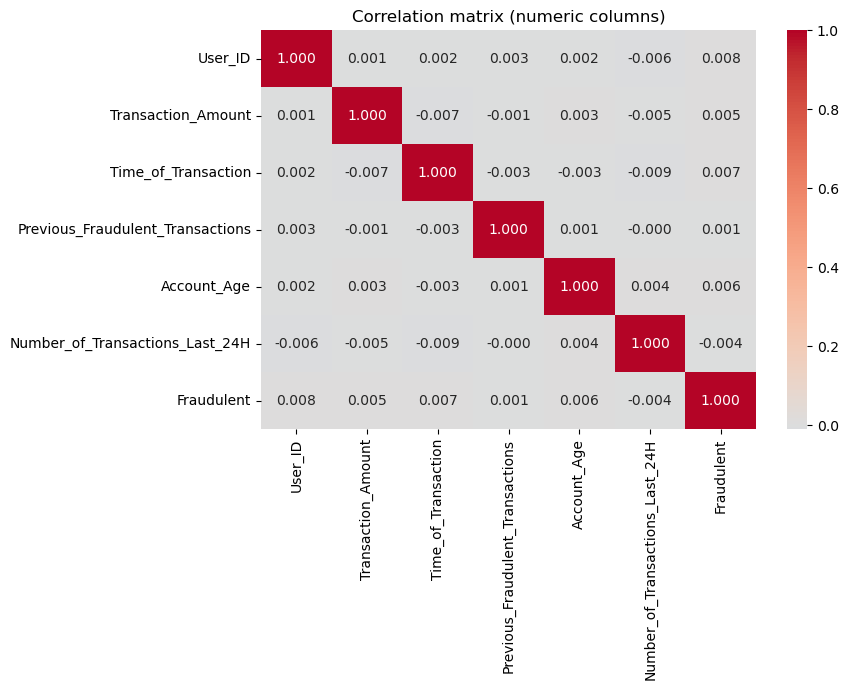

User_ID                             0.0080
Time_of_Transaction                 0.0069
Account_Age                         0.0062
Transaction_Amount                  0.0054
Number_of_Transactions_Last_24H    -0.0039
Previous_Fraudulent_Transactions    0.0011


In [18]:
numeric = df_clean.select_dtypes(include="number")

plt.figure(figsize=(9, 7))
sns.heatmap(numeric.corr(), annot=True, fmt=".3f", cmap="coolwarm", center=0)
plt.title("Correlation matrix (numeric columns)")
plt.tight_layout(); plt.show()

print(numeric.corr()["Fraudulent"].drop("Fraudulent").sort_values(key=abs, ascending=False).round(4).to_string())

Every correlation with `Fraudulent` is below 0.02 in absolute value, consistent with the chi-square result above.

# Outlier

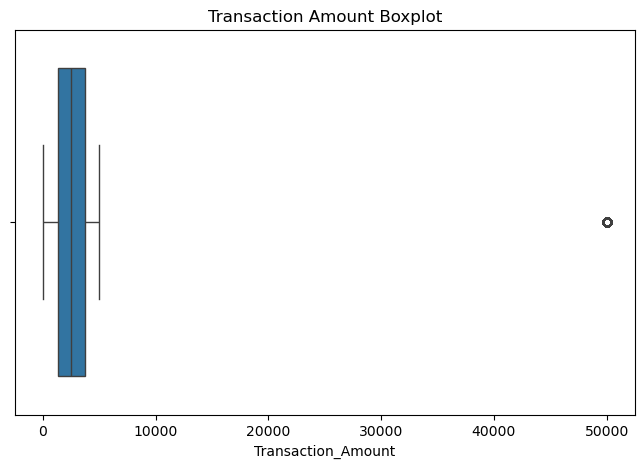

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_clean["Transaction_Amount"])
plt.title("Transaction Amount Boxplot")
plt.show()

In [20]:
Q1 = df_clean["Transaction_Amount"].quantile(0.25)
Q3 = df_clean["Transaction_Amount"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean["Transaction_Amount"] < lower) |
                    (df_clean["Transaction_Amount"] > upper)]

print("Q1 = %.2f | Q3 = %.2f | IQR = %.2f" % (Q1, Q3, IQR))
print("bounds: lower = %.2f, upper = %.2f" % (lower, upper))
print("outliers:", outliers.shape[0])
print("fraud rate inside outliers: %.4f vs %.4f overall"
      % (outliers["Fraudulent"].mean(), df_clean["Fraudulent"].mean()))

Q1 = 1333.79 | Q3 = 3724.99 | IQR = 2391.20
bounds: lower = -2253.01, upper = 7311.79
outliers: 508
fraud rate inside outliers: 0.0630 vs 0.0492 overall


The lower bound is negative and `Transaction_Amount` is non-negative, so **every** outlier is an upper outlier. Reporting '0 lower outliers' as a finding would be misleading — it is forced by the variable's range.

### Task 3: Common and uncommon values

Every one of those outliers turns out to be the *same number*.

**Use the raw column, not the imputed one.** Median imputation inserted 2,520 copies of the median into `Transaction_Amount`, which would otherwise appear at the top of this table as the most 'common' value — an artefact of our own preprocessing, not of the data. Frequency analysis has to run on the original column.

In [21]:
print("imputation injected %d copies of the median (%.2f) — excluded from this analysis"
      % (df["Transaction_Amount"].isna().sum(), df["Transaction_Amount"].median()))

vc = df["Transaction_Amount"].value_counts()          # raw column, pre-imputation
print("\n10 most frequent Transaction_Amount values (raw data):")
print(vc.head(10).to_string())

distinct = np.sort(df["Transaction_Amount"].dropna().unique())
print("\nlargest value        :", distinct[-1])
print("second largest value :", distinct[-2])
print("ratio                : %.4f" % (distinct[-1] / distinct[-2]))

imputation injected 2520 copies of the median (2524.10) — excluded from this analysis

10 most frequent Transaction_Amount values (raw data):
Transaction_Amount
49997.80    508
495.14        4
3562.91       4
2748.08       4
1747.31       4
2092.21       4
246.87        3
1369.45       3
398.68        3
4083.96       3

largest value        : 49997.8
second largest value : 4999.78
ratio                : 10.0000


### The `49997.8` artefact

This is the key data-quality finding of the notebook. The largest value is **exactly 10x** the second largest (49997.80 vs 4999.78), and it repeats 508 times while every other amount appears at most 4 times. A genuine transaction amount would not behave like that.

It is a **misplaced decimal point** — 508 rows whose amount was multiplied by ten — not a set of unusually large transactions.

In [22]:
artefact = df[df["Transaction_Amount"] == distinct[-1]]
print("rows at the artefact value:", len(artefact))
print("fraud rate among them: %.4f vs %.4f overall"
      % (artefact["Fraudulent"].mean(), df_clean["Fraudulent"].mean()))
print("\nlegitimate range excluding it: %.2f to %.2f" % (distinct[0], distinct[-2]))

print("\nthese 508 rows are spread across all categories, not concentrated:")
print(artefact["Transaction_Type"].value_counts().to_string())

rows at the artefact value: 508
fraud rate among them: 0.0630 vs 0.0492 overall

legitimate range excluding it: 5.03 to 4999.78

these 508 rows are spread across all categories, not concentrated:
Transaction_Type
Bank Transfer      112
Bill Payment       107
ATM Withdrawal     100
Online Purchase    100
POS Payment         89


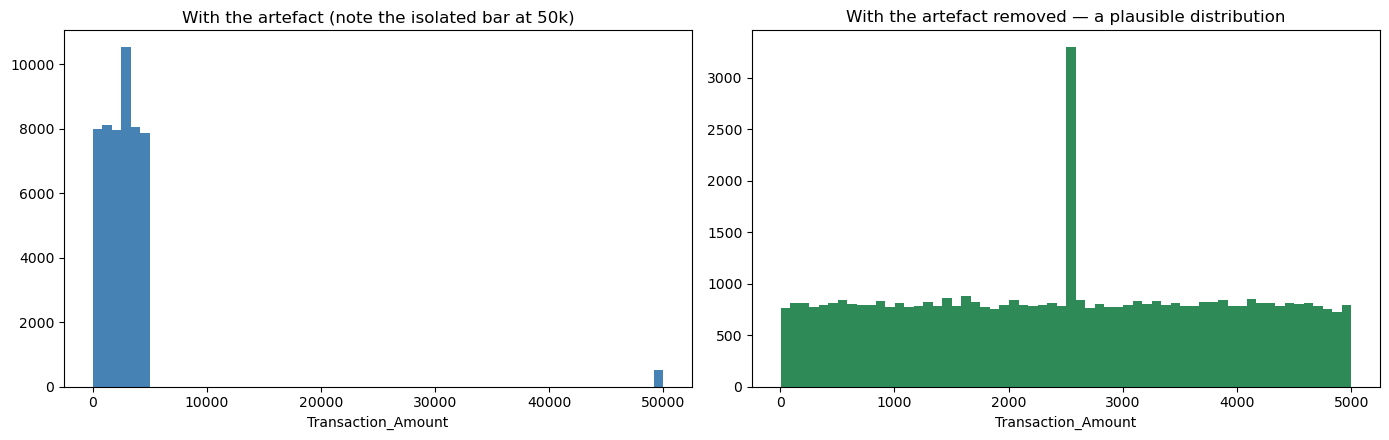

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].hist(df_clean["Transaction_Amount"], bins=60, color="steelblue")
ax[0].set_title("With the artefact (note the isolated bar at 50k)")
ax[0].set_xlabel("Transaction_Amount")

clean_amounts = df_clean.loc[df_clean["Transaction_Amount"] != distinct[-1], "Transaction_Amount"]
ax[1].hist(clean_amounts, bins=60, color="seagreen")
ax[1].set_title("With the artefact removed — a plausible distribution")
ax[1].set_xlabel("Transaction_Amount")
plt.tight_layout(); plt.show()

### Task 4: Outliers in `Time_of_Transaction`, with graph

In [24]:
Q1_t = df_clean["Time_of_Transaction"].quantile(0.25)
Q3_t = df_clean["Time_of_Transaction"].quantile(0.75)
IQR_t = Q3_t - Q1_t
lower_t, upper_t = Q1_t - 1.5 * IQR_t, Q3_t + 1.5 * IQR_t

outliers_time = df_clean[(df_clean["Time_of_Transaction"] < lower_t) |
                         (df_clean["Time_of_Transaction"] > upper_t)]
print("Time_of_Transaction range: %.1f to %.1f" % (df_clean["Time_of_Transaction"].min(),
                                                   df_clean["Time_of_Transaction"].max()))
print("IQR bounds: %.2f to %.2f" % (lower_t, upper_t))
print("outliers:", len(outliers_time))

Time_of_Transaction range: 0.0 to 23.0
IQR bounds: -10.50 to 33.50
outliers: 0


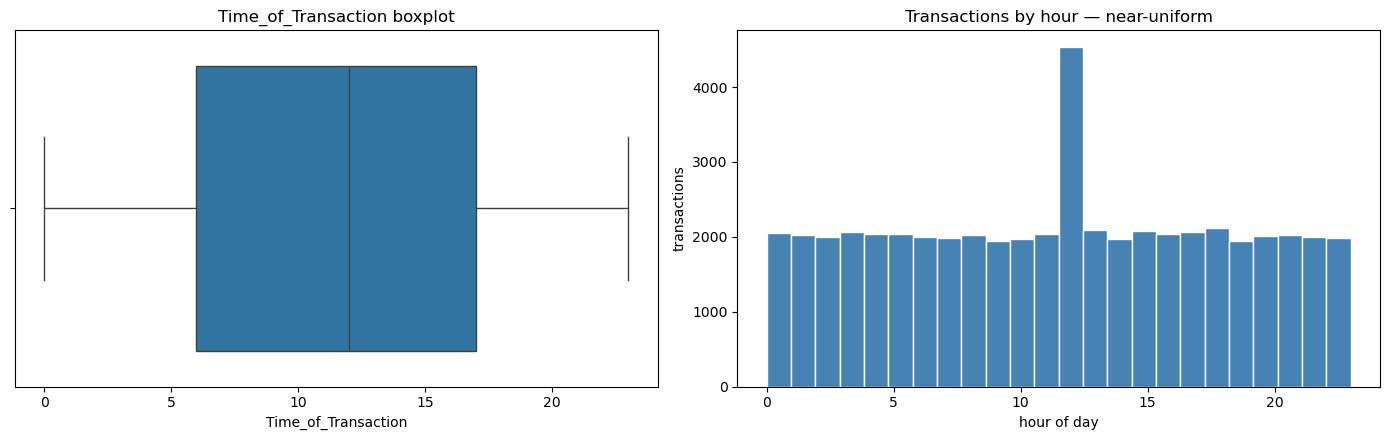

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(x=df_clean["Time_of_Transaction"], ax=ax[0])
ax[0].set_title("Time_of_Transaction boxplot")

ax[1].hist(df_clean["Time_of_Transaction"], bins=24, color="steelblue", edgecolor="white")
ax[1].set_xlabel("hour of day"); ax[1].set_ylabel("transactions")
ax[1].set_title("Transactions by hour — near-uniform")
plt.tight_layout(); plt.show()

`Time_of_Transaction` produces **zero** outliers, and the histogram shows why: the hours are close to uniformly distributed across the 24-hour clock. The IQR rule assumes a peaked distribution and cannot flag anything in a flat one. A useful negative result — the method, not just the data, determines what counts as an outlier.

It also confirms the data is synthetic: real transaction times have a pronounced day/night cycle, as seen in both FDCH1 datasets.

# DBSCAN anomaly detection

In [26]:
features = [
    "Transaction_Amount",
    "Previous_Fraudulent_Transactions",
    "Account_Age",
    "Number_of_Transactions_Last_24H",
]
print("feature set A:", features)

feature set A: ['Transaction_Amount', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H']


In [27]:
from sklearn.preprocessing import StandardScaler

X = df_clean[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("scaled:", X_scaled.shape)

scaled: (51000, 4)


In [28]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=15)
labels = dbscan.fit_predict(X_scaled)

df_clean["Cluster"] = labels
print(df_clean["Cluster"].value_counts().to_string())

Cluster
 0    50492
 1      505
-1        3


In [29]:
# What is the small second cluster? Compare each cluster's amount profile.
print(df_clean.groupby("Cluster")["Transaction_Amount"]
        .agg(["size", "min", "max", "mean"]).round(2).to_string())

          size       min       max     mean
Cluster                                    
-1           3  49997.80  49997.80  49997.8
 0       50492      5.03   4999.78   2499.8
 1         505  49997.80  49997.80  49997.8


DBSCAN did **not** put the corrupted rows in the noise bucket. Because all 508 of them share the *identical* value 49,997.80, they are mutually dense — each one has 507 neighbours at distance zero — so DBSCAN promotes them to a **cluster of their own** (`Cluster 1`, 505 rows) and leaves only 3 stragglers as noise.

This is a property of DBSCAN worth understanding: density, not distance from the centre, decides what counts as noise. A tight clump of repeated corrupted values is *dense*, so it reads as a cluster no matter how far out it sits.

### Task 5: Anomalies (Cluster = -1)

In [30]:
suspicious = df_clean[df_clean["Cluster"] == -1]
print("anomalies:", len(suspicious))
print("fraud rate — anomalies: %.4f | rest: %.4f"
      % (suspicious["Fraudulent"].mean(), df_clean[df_clean.Cluster != -1]["Fraudulent"].mean()))

print("\nTransaction_Amount of the anomalies:")
print(suspicious["Transaction_Amount"].describe().round(2).to_string())
suspicious.head()

anomalies: 3
fraud rate — anomalies: 0.0000 | rest: 0.0492

Transaction_Amount of the anomalies:
count        3.0
mean     49997.8
std          0.0
min      49997.8
25%      49997.8
50%      49997.8
75%      49997.8
max      49997.8


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent,Cluster
15441,T15442,4030,49997.8,Bank Transfer,20.0,Desktop,Seattle,0,5,3,Credit Card,0,-1
28247,T28248,1065,49997.8,Online Purchase,11.0,Unknown Device,Los Angeles,0,3,1,Credit Card,0,-1
34603,T34604,1646,49997.8,Bill Payment,16.0,Mobile,Seattle,0,9,5,Debit Card,0,-1


**DBSCAN rediscovers the data-quality artefact, not fraud.** Both the 3 noise points and the entire 505-row `Cluster 1` sit at the corrupted `49997.8` value found in Task 3. Everything DBSCAN separated from the main body of the data is the decimal-point error — and none of it is fraud: the anomalies contain **zero** frauds against a 4.92% base rate.

This is the honest reading: on this dataset DBSCAN is a **data-quality detector**, not a fraud detector. Compare with FDCH1's data, where the same technique separates real fraud.

### Task 6: Anomalies with a different feature set

In [31]:
# Deliberately EXCLUDES Transaction_Amount — the corrupted column.
features_B = ["Previous_Fraudulent_Transactions", "Account_Age", "Number_of_Transactions_Last_24H"]
X_B = StandardScaler().fit_transform(df_clean[features_B])

labels_B = DBSCAN(eps=0.8, min_samples=15).fit_predict(X_B)
df_clean["Cluster_B"] = labels_B

print("feature set B:", features_B)
print(df_clean["Cluster_B"].value_counts().to_string())

sus_B = df_clean[df_clean["Cluster_B"] == -1]
print("\nanomalies:", len(sus_B), "| fraud rate %.4f" % sus_B["Fraudulent"].mean())
print("overlap with feature set A:", len(set(suspicious.index) & set(sus_B.index)), "rows")

art_idx = set(df_clean.index[df_clean["Transaction_Amount"] == distinct[-1]])
print("\nwhere the 508 artefact rows land without Transaction_Amount:")
print(df_clean.loc[sorted(art_idx), "Cluster_B"].value_counts().to_string())

feature set B: ['Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H']
Cluster_B
0    51000

anomalies: 0 | fraud rate nan
overlap with feature set A: 0 rows

where the 508 artefact rows land without Transaction_Amount:
Cluster_B
0    508


Remove the corrupted column and the anomalies **disappear**: the same 508 rows fall into ordinary clusters, because they are perfectly normal in every dimension except the one with the misplaced decimal. That is the cleanest confirmation of the diagnosis — the anomaly was never a property of those transactions, only of one corrupted field.

### `eps` sensitivity

`eps=0.8` was inherited without justification. Sweeping it shows how much the result depends on that single number.

In [32]:
rows = []
for eps in [0.3, 0.5, 0.8, 1.0, 1.5, 2.0]:
    lab = DBSCAN(eps=eps, min_samples=15).fit_predict(X_scaled)
    is_noise = lab == -1
    rows.append({"eps": eps,
                 "clusters": len(set(lab)) - (1 if -1 in lab else 0),
                 "anomalies": int(is_noise.sum()),
                 "fraud_rate_in_anomalies": round(df_clean.loc[is_noise, "Fraudulent"].mean(), 4)
                                            if is_noise.sum() else np.nan})
print(pd.DataFrame(rows).to_string(index=False))
print("\nbaseline fraud rate: %.4f" % df_clean["Fraudulent"].mean())

 eps  clusters  anomalies  fraud_rate_in_anomalies
 0.3         5        508                    0.063
 0.5         5        508                    0.063
 0.8         2          3                    0.000
 1.0         2          0                      NaN
 1.5         2          0                      NaN
 2.0         2          0                      NaN

baseline fraud rate: 0.0492


At small `eps` (0.3-0.5) all 508 corrupted rows are flagged, with a fraud rate of 0.063 against the 0.0492 baseline — a 1.3x lift, nowhere near enough to call it fraud detection. By `eps >= 1.0` the artefact group is dense enough to be absorbed as a cluster and **nothing is flagged at all**. No setting turns this into a fraud detector, so the result is a property of the data rather than a badly chosen parameter.

### Task 7: Cluster graph (any two attributes)

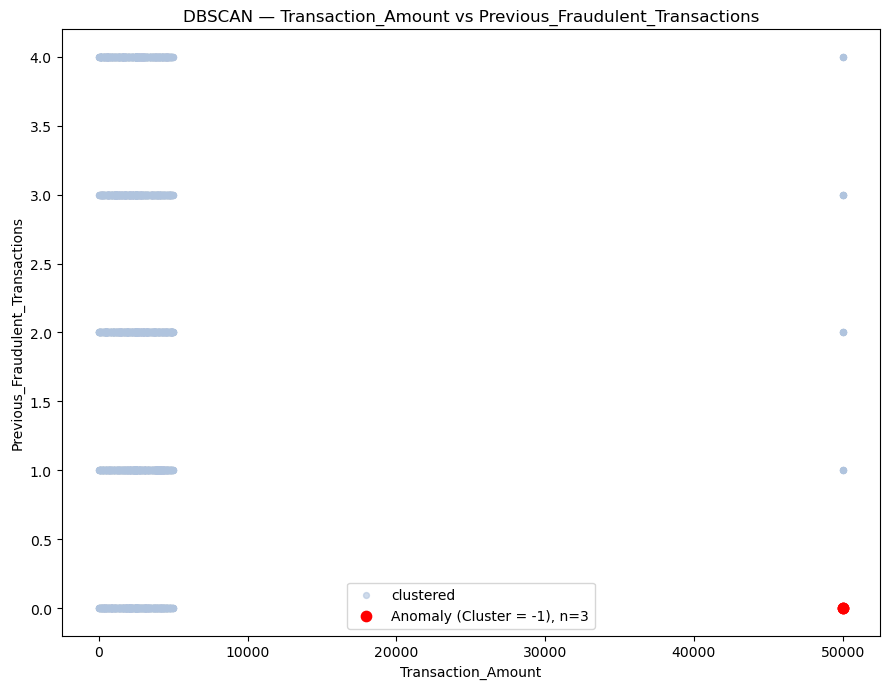

In [33]:
x_attr = "Transaction_Amount"
y_attr = "Previous_Fraudulent_Transactions"

non_noise = df_clean[df_clean["Cluster"] != -1]
noise = df_clean[df_clean["Cluster"] == -1]

plot_sample = non_noise.sample(n=min(4000, len(non_noise)), random_state=42)

plt.figure(figsize=(9, 7))
plt.scatter(plot_sample[x_attr], plot_sample[y_attr],
            c="lightsteelblue", s=18, alpha=.6, label="clustered")
plt.scatter(noise[x_attr], noise[y_attr], c="red", marker="o", s=55,
            label="Anomaly (Cluster = -1), n=%d" % len(noise))

plt.xlabel(x_attr); plt.ylabel(y_attr)
plt.title("DBSCAN — %s vs %s" % (x_attr, y_attr))
plt.legend(); plt.tight_layout(); plt.show()

The red points sit in complete isolation on the right of the plot — the visual signature of the decimal-point artefact, ten times beyond the real data.

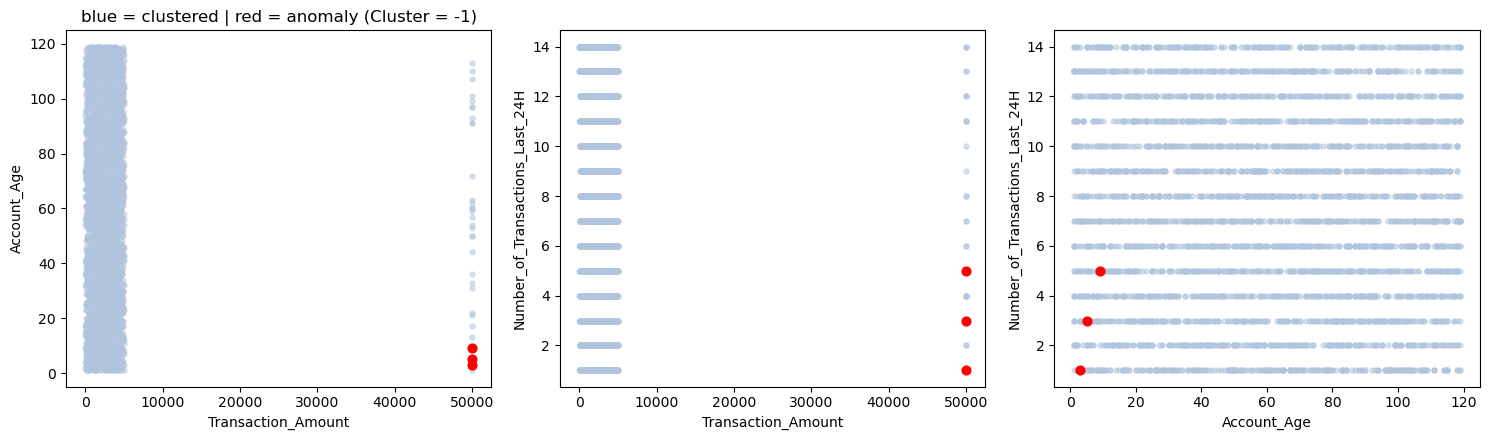

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
pairs = [("Transaction_Amount", "Account_Age"),
         ("Transaction_Amount", "Number_of_Transactions_Last_24H"),
         ("Account_Age", "Number_of_Transactions_Last_24H")]
for ax, (xa, ya) in zip(axes, pairs):
    ax.scatter(plot_sample[xa], plot_sample[ya], c="lightsteelblue", s=12, alpha=.5)
    ax.scatter(noise[xa], noise[ya], c="red", s=40)
    ax.set_xlabel(xa); ax.set_ylabel(ya)
axes[0].set_title("blue = clustered | red = anomaly (Cluster = -1)")
plt.tight_layout(); plt.show()

The third panel — `Account_Age` vs `Number_of_Transactions_Last_24H`, with `Transaction_Amount` absent from both axes — shows the anomalies mixed in with everything else. They are only extreme in the one corrupted dimension, which confirms the diagnosis.

# Result Analysis

**Missing data.** Five columns were missing roughly 5% of their values. One caution on the fix:
median imputation inserts 2,520 identical values into `Transaction_Amount`, which then becomes the
single most frequent value in the column. The frequency analysis in Task 3 therefore runs on the raw
column — imputation must not be allowed to contaminate the analysis that looks for repeated values. An MCAR check showed the fraud
rate was effectively identical whether a value was missing or present, so the missingness is not
informative about the target. `dropna()` would have cost **11,417 rows (22.4%)** — because most
affected rows are complete except in one column — so median/mode imputation was used instead, keeping
all 51,000 rows. The blanket `dropna()` in the original template was safe here but wasteful, and would
have been actively harmful had the MCAR check come out differently.

**Duplicates.** `Transaction_ID` is **not** a unique key: 1,000 IDs appear twice, and the colliding
rows are identical in every other column as well. The 51,000-row file is really 50,000 distinct
transactions with 1,000 exact copies appended. Duplicated rows inflate any count or rate computed
from the data, and would leak across a train/test split if the file were ever used for modelling.

**The `49997.8` artefact — the main data-quality finding.** The largest transaction amount is exactly
**ten times** the second largest (49,997.80 vs 4,999.78) and repeats **508 times**, while no other
amount appears more than 4 times. That is a misplaced decimal point affecting 508 rows, not a
population of large transactions. Every IQR outlier in `Transaction_Amount` is one of these rows.

**Outliers.** `Transaction_Amount` yields only upper outliers, forced by the variable being
non-negative. `Time_of_Transaction` yields **none at all**: the hours are near-uniform across the
clock, and the IQR rule cannot find outliers in a flat distribution. That uniformity is itself
evidence the data is synthetic — real transaction times show a strong day/night cycle.

**No signal in the labels.** Chi-square found no significant association between `Fraudulent` and any
of `Payment_Method`, `Transaction_Type`, `Device_Used` or `Location`; every numeric correlation with
the target is below 0.02. The labels appear to have been assigned independently of the features. This
is why the notebook is framed as unsupervised analysis: a classifier trained here would score ~95%
accuracy purely by predicting the majority class while learning nothing.

**DBSCAN.** Everything the algorithm separated from the main body of the data is the decimal-point
error. Notably it did *not* label those rows as noise: because all 508 share an identical value they
are mutually dense, so DBSCAN promoted them to a cluster of their own (505 rows) and left just 3 as
noise. Density, not distance from the centre, decides what DBSCAN calls an anomaly — a tight clump of
repeated corrupted values reads as a cluster however far out it sits.

The anomalies contain **zero** frauds against a 4.92% base rate, and an `eps` sweep from 0.3 to 2.0
never lifts that above 0.063. Re-running on a feature set that excludes `Transaction_Amount` makes the
anomalies vanish entirely — the same 508 rows fall into ordinary clusters, because they are perfectly
normal in every dimension except the corrupted one. That is the cleanest confirmation of the
diagnosis. **On this dataset DBSCAN works as a data-quality detector, not a fraud detector** — a
genuinely useful result, and the honest one to report.